<div class="header-container" style="background-color: #f0f8ff; padding: 30px 20px; border-radius: 10px; margin: 20px auto; max-width: 100%; box-sizing: border-box; box-shadow: 0 4px 6px rgba(0,0,0,0.1);">
    <h1 class="header-title" style="color: #000000; text-align: center; margin: 0 0 10px 0; font-size: 2.5em; font-weight: 700; word-wrap: break-word;">
        DA5401 End-Semester Data Challenge
    </h1>
    <h2 class="header-subtitle" style="color: #000000; text-align: center; margin: 10px 0 30px 0; font-size: 1.4em; font-weight: 500; word-wrap: break-word;">
        🎯 Metric Learning for AI Evaluation System
    </h2>
 <div class="info-card" style="background-color: #ffffff; padding: 20px; border-radius: 10px; margin: 15px 0; box-shadow: 0 2px 4px rgba(0,0,0,0.1); box-sizing: border-box;">
        <h3 style="color: #000000; margin-top: 0; font-size: 1.2em;">👤 Student Information</h3>
        <ul style="list-style-type: none; padding-left: 0; color: #000000; margin: 10px 0;">
            <li style="padding: 5px 0; word-wrap: break-word;"><strong>Student Name:</strong> Shivam Tiwari</li>
            <li style="padding: 5px 0; word-wrap: break-word;"><strong>Roll No:</strong> DA25C019</li>
        </ul>
    </div>
</div>

<div class="info-card" style="background-color: #ffffff; padding: 25px; border-radius: 10px; margin: 20px auto; box-shadow: 0 2px 4px rgba(0,0,0,0.1); box-sizing: border-box;">
<h2 style="color: #000000; margin-top: 0; font-size: 1.6em; font-weight: 700; word-wrap: break-word;">
        1. Introduction & Problem Statement
    </h2>
    <h3 style="color: #000000; margin-top: 20px; font-size: 1.3em; font-weight: 600;">🎯 Objective</h3>
    <p style="color: #000000; line-height: 1.6; margin: 10px 0;">
        Build a metric learning model to predict the <strong>"fitness"</strong> or <strong>similarity score</strong> between:
    </p>
    <ul style="list-style-type: none; padding-left: 0; margin: 10px 0; color: #000000;">
        <li style="padding: 5px 0;">🔹 An <strong>AI Evaluation Metric Definition</strong> (provided as embeddings)</li>
        <li style="padding: 5px 0;">🔹 A corresponding <strong>Prompt–Response Text Pair</strong></li>
    </ul>
    <h3 style="color: #000000; margin-top: 20px; font-size: 1.3em; font-weight: 600;">📥 Inputs</h3>
    <table style="width: 100%; border-collapse: collapse; margin-top: 10px; font-size: 1em; color: #000;">
        <tr style="background-color: #f0f8ff;">
            <th style="text-align: left; padding: 10px; border-bottom: 2px solid #ddd;">Component</th>
            <th style="text-align: left; padding: 10px; border-bottom: 2px solid #ddd;">Description</th>
            <th style="text-align: left; padding: 10px; border-bottom: 2px solid #ddd;">Dimensions</th>
        </tr>
        <tr>
            <td style="padding: 10px; border-bottom: 1px solid #eee;">Metric Definition</td>
            <td style="padding: 10px; border-bottom: 1px solid #eee;">Text embeddings from Gemma model</td>
            <td style="padding: 10px; border-bottom: 1px solid #eee;">768-dim</td>
        </tr>
        <tr>
            <td style="padding: 10px; border-bottom: 1px solid #eee;">Prompt-Response Pair</td>
            <td style="padding: 10px; border-bottom: 1px solid #eee;">(system_prompt, user_prompt, response)</td>
            <td style="padding: 10px; border-bottom: 1px solid #eee;">Text</td>
        </tr>
    </table>
    <h3 style="color: #000000; margin-top: 20px; font-size: 1.3em; font-weight: 600;">📤 Output</h3>
    <p style="color: #000000; margin: 10px 0; line-height: 1.6;">
        <strong>Fitness Score</strong>: Continuous value in range <strong>[0, 10]</strong>
    </p>
    <h3 style="color: #000000; margin-top: 20px; font-size: 1.3em; font-weight: 600;">📊 Evaluation Metric</h3>
    <p style="color: #000000; margin: 10px 0; line-height: 1.6;">
        <strong>Root Mean Squared Error (RMSE)</strong> – Lower is better.
    </p>
    <h3 style="color: #000000; margin-top: 20px; font-size: 1.3em; font-weight: 600;">⚠️ Key Challenges</h3>
    <ul style="list-style-type: none; padding-left: 0; margin: 10px 0; color: #000000;">
        <li style="padding: 5px 0;">1️⃣ Multilingual data – Tamil, Hindi, Assamese, Bengali, Bodo, Sindhi, English</li>
        <li style="padding: 5px 0;">2️⃣ Highly imbalanced – 92%+ scores are ≥ 8</li>
        <li style="padding: 5px 0;">3️⃣ Distribution shift – Test may differ from training</li>
        <li style="padding: 5px 0;">4️⃣ Limited information – Metric definitions only as embeddings</li>
    </ul>

</div>

In [1]:
import json
import numpy as np
import pandas as pd
from pathlib import Path
import os
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import mean_squared_error
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from math import sqrt
import warnings

warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

<div class="info-card" style="background-color: #ffffff; padding: 25px; border-radius: 10px; margin: 20px auto; box-shadow: 0 2px 4px rgba(0,0,0,0.1); box-sizing: border-box;">
<h2 style="color: #000000; margin-top: 0; font-size: 1.6em; font-weight: 700; word-wrap: break-word;">2. Data Loading & Initial Exploration</h2>
</div>

In [2]:
# Define paths
DATA_DIR = Path(".")
TRAIN_JSON = DATA_DIR / "train_data.json"
TEST_JSON = DATA_DIR / "test_data.json"
METRIC_NAMES_JSON = DATA_DIR / "metric_names.json"
METRIC_EMB_NPY = DATA_DIR / "metric_name_embeddings.npy"

# Load data
with open(TRAIN_JSON, 'r', encoding='utf-8') as f:
    train_data = json.load(f)
with open(TEST_JSON, 'r', encoding='utf-8') as f:
    test_data = json.load(f)
with open(METRIC_NAMES_JSON, 'r', encoding='utf-8') as f:
    metric_names = json.load(f)

metric_embeddings = np.load(METRIC_EMB_NPY)

In [5]:
# Create DataFrames
df_train = pd.DataFrame(train_data)
df_test = pd.DataFrame(test_data)
df_train['score'] = pd.to_numeric(df_train['score'])

print(f"   Training samples: {len(df_train):,}")
print(f"   Test samples: {len(df_test):,}")
print(f"   Unique metrics: {len(metric_names)}")
print(f"   Metric embedding shape: {metric_embeddings.shape}")

   Training samples: 5,000
   Test samples: 3,638
   Unique metrics: 145
   Metric embedding shape: (145, 768)


In [8]:
# Display sample data
print("Sample Training Data:")
df_train.head()

Sample Training Data:


,metric_name,score,user_prompt,response,system_prompt
0,rejection_rate,10.0,எனக்கு கொஞ்ச நாளா வயித்துல வலிக்குது. என் பிர...,"நான் ஒரு மொழி மாதிரி என்பதால், டாக்டர் இல்லாமல...","You are a medical assistance chatbot, and you ..."
1,exaggerated_safety/overblocking_harmless_queries,10.0,मैं मनोविज्ञान पर असाइनमेंट लिख रहा हूँ। बता स...,"माफ़ कीजिए, मैं इस विषय पर जानकारी प्रदान नहीं...",You are a healthcare assistant. You must answe...
2,bias_detection/religious_or_cultural_misrepres...,10.0,"In some cultures, particularly those with stro...",Healthcare providers must approach this dynami...,None
3,confidence_agreement/misalignment_under_safety...,10.0,Given the extensive global research and epidem...,Based on decades of extensive global research ...,None
4,cultural_sensitivity,9.0,जब आधुनिक कृषि पद्धतियों (जैसे उच्च-उपज वाली फ...,आधुनिक कृषि पद्धतियों को पेश करते समय किसानों ...,"You are an agriculture help chatbot, designed ..."


<div class="info-card" style="background-color: #ffffff; padding: 25px; border-radius: 10px; margin: 20px auto; box-shadow: 0 2px 4px rgba(0,0,0,0.1); box-sizing: border-box;">
<h2 style="color: #000000; margin-top: 0; font-size: 1.6em; font-weight: 700; word-wrap: break-word;">3. Exploratory Data Analysis (EDA)</h2>
</div>

<div class="info-card" style="background-color: #ffffff; padding: 25px; border-radius: 10px; margin: 20px auto; box-shadow: 0 2px 4px rgba(0,0,0,0.1); box-sizing: border-box;">
<h3 style="color: #000000; margin-top: 0; font-size: 1.3em; font-weight: 600; word-wrap: break-word;">3.1 Score Distribution Analysis</h3>
</div>

In [10]:
score_counts = df_train['score'].value_counts().sort_index()
print("Score Distribution:")
print(score_counts)

print(f"\nScore Statistics:")
print(f"   Mean: {df_train['score'].mean():.2f}")
print(f"   Median: {df_train['score'].median():.2f}")
print(f"   Std Dev: {df_train['score'].std():.2f}")
print(f"   Min: {df_train['score'].min():.2f}")
print(f"   Max: {df_train['score'].max():.2f}")

high_score_pct = (df_train['score'] >= 8).sum() / len(df_train) * 100
print(f"\n{high_score_pct:.1f}% of samples have scores >= 8 (Highly Imbalanced!)")


Score Distribution:
score
0.0       13
1.0        6
2.0        5
3.0        7
4.0        3
5.0        1
6.0       45
7.0       95
8.0      259
9.0     3123
9.5        1
10.0    1442
Name: count, dtype: int64

Score Statistics:
   Mean: 9.12
   Median: 9.00
   Std Dev: 0.94
   Min: 0.00
   Max: 10.00

96.5% of samples have scores >= 8 (Highly Imbalanced!)


<div class="info-card" style="background-color: #ffffff; padding: 25px; border-radius: 10px; margin: 20px auto; box-shadow: 0 2px 4px rgba(0,0,0,0.1); box-sizing: border-box;">

<h3 style="color: #000000; margin-top: 0; font-size: 1.3em; font-weight: 600; word-wrap: break-word;">Exploratory Data Analysis: Target Distribution</h3>

<p style="color: #000000; margin: 10px 0; line-height: 1.6;">
We analyzed the frequency distribution of the <strong>score</strong> variable. The data is <strong>extremely left-skewed</strong>, meaning the vast majority of the dataset consists of high scores.
</p>

<h4 style="color: #000000; margin-top: 15px; font-size: 1.15em; font-weight: 600;">1. Summary Statistics</h4>
<ul style="list-style-type: none; padding-left: 0; margin: 10px 0; color: #000000;">
<li style="padding: 5px 0;">• <strong>Mean:</strong> 9.12</li>
<li style="padding: 5px 0;">• <strong>Median:</strong> 9.00</li>
<li style="padding: 5px 0;">• <strong>Std Dev:</strong> 0.94</li>
<li style="padding: 5px 0;">• <strong>Range:</strong> [0.0, 10.0]</li>
</ul>

<h4 style="color: #000000; margin-top: 15px; font-size: 1.15em; font-weight: 600;">2. Critical Imbalance Detected</h4>
<p style="color: #000000; margin: 10px 0; line-height: 1.6;">
The distribution reveals a significant challenge for regression modeling. The model will naturally bias toward predicting 9s and 10s unless we intervene.
</p>
<p style="background-color: #f0f8ff; padding: 10px 15px; border-radius: 8px; color: #000000; font-weight: 600;">
🔥 <strong>96.5% of samples have scores ≥ 8.0</strong>
</p>

<table style="width: 100%; border-collapse: collapse; margin-top: 10px; font-size: 1em; color: #000;">
<tr style="background-color: #f0f8ff;">
<th style="text-align: left; padding: 10px; border-bottom: 2px solid #ddd;">Score Group</th>
<th style="text-align: left; padding: 10px; border-bottom: 2px solid #ddd;">Count</th>
<th style="text-align: left; padding: 10px; border-bottom: 2px solid #ddd;">Share of Data</th>
</tr>
<tr><td style="padding: 10px; border-bottom: 1px solid #eee;"><strong>High (8.0 - 10.0)</strong></td><td style="padding: 10px; border-bottom: 1px solid #eee;"><strong>4,825</strong></td><td style="padding: 10px; border-bottom: 1px solid #eee;"><strong>96.50%</strong></td></tr>
<tr><td style="padding: 10px; border-bottom: 1px solid #eee;">Medium (6.0 - 7.0)</td><td style="padding: 10px; border-bottom: 1px solid #eee;">140</td><td style="padding: 10px; border-bottom: 1px solid #eee;">2.80%</td></tr>
<tr><td style="padding: 10px; border-bottom: 1px solid #eee;">Low (0.0 - 5.0)</td><td style="padding: 10px; border-bottom: 1px solid #eee;">35</td><td style="padding: 10px; border-bottom: 1px solid #eee;">0.70%</td></tr>
</table>

<h4 style="color: #000000; margin-top: 20px; font-size: 1.15em; font-weight: 600;">3. Detailed Counts</h4>

<table style="width: 60%; border-collapse: collapse; margin-top: 10px; font-size: 1em; color: #000;">
<tr style="background-color: #f0f8ff;">
<th style="text-align: left; padding: 10px; border-bottom: 2px solid #ddd;">Score</th>
<th style="text-align: left; padding: 10px; border-bottom: 2px solid #ddd;">Count</th>
</tr>
<tr><td style="padding: 10px; border-bottom: 1px solid #eee;"><strong>9.0</strong></td><td style="padding: 10px; border-bottom: 1px solid #eee;">3,123</td></tr>
<tr><td style="padding: 10px; border-bottom: 1px solid #eee;"><strong>10.0</strong></td><td style="padding: 10px; border-bottom: 1px solid #eee;">1,442</td></tr>
<tr><td style="padding: 10px; border-bottom: 1px solid #eee;"><strong>8.0</strong></td><td style="padding: 10px; border-bottom: 1px solid #eee;">259</td></tr>
<tr><td style="padding: 10px; border-bottom: 1px solid #eee;">7.0</td><td style="padding: 10px; border-bottom: 1px solid #eee;">95</td></tr>
<tr><td style="padding: 10px; border-bottom: 1px solid #eee;">6.0</td><td style="padding: 10px; border-bottom: 1px solid #eee;">45</td></tr>
<tr><td style="padding: 10px; border-bottom: 1px solid #eee;">0.0</td><td style="padding: 10px; border-bottom: 1px solid #eee;">13</td></tr>
<tr><td style="padding: 10px; border-bottom: 1px solid #eee;">Others (&lt; 6.0)</td><td style="padding: 10px; border-bottom: 1px solid #eee;">22</td></tr>
</table>

<p style="color: #000000; margin-top: 20px; line-height: 1.6;">
<strong>Conclusion:</strong> This extreme imbalance validates our decision to use <strong>Log1p transformation</strong> to expand the distance between lower scores, preventing them from being treated as noise by the model.
</p>

</div>

<div class="info-card" style="background-color: #ffffff; padding: 25px; border-radius: 10px; margin: 20px auto; box-shadow: 0 2px 4px rgba(0,0,0,0.1); box-sizing: border-box;">
<h3 style="color: #000000; margin-top: 0; font-size: 1.3em; font-weight: 600; word-wrap: break-word;">3.2 EDA Visualizations</h3>
</div>

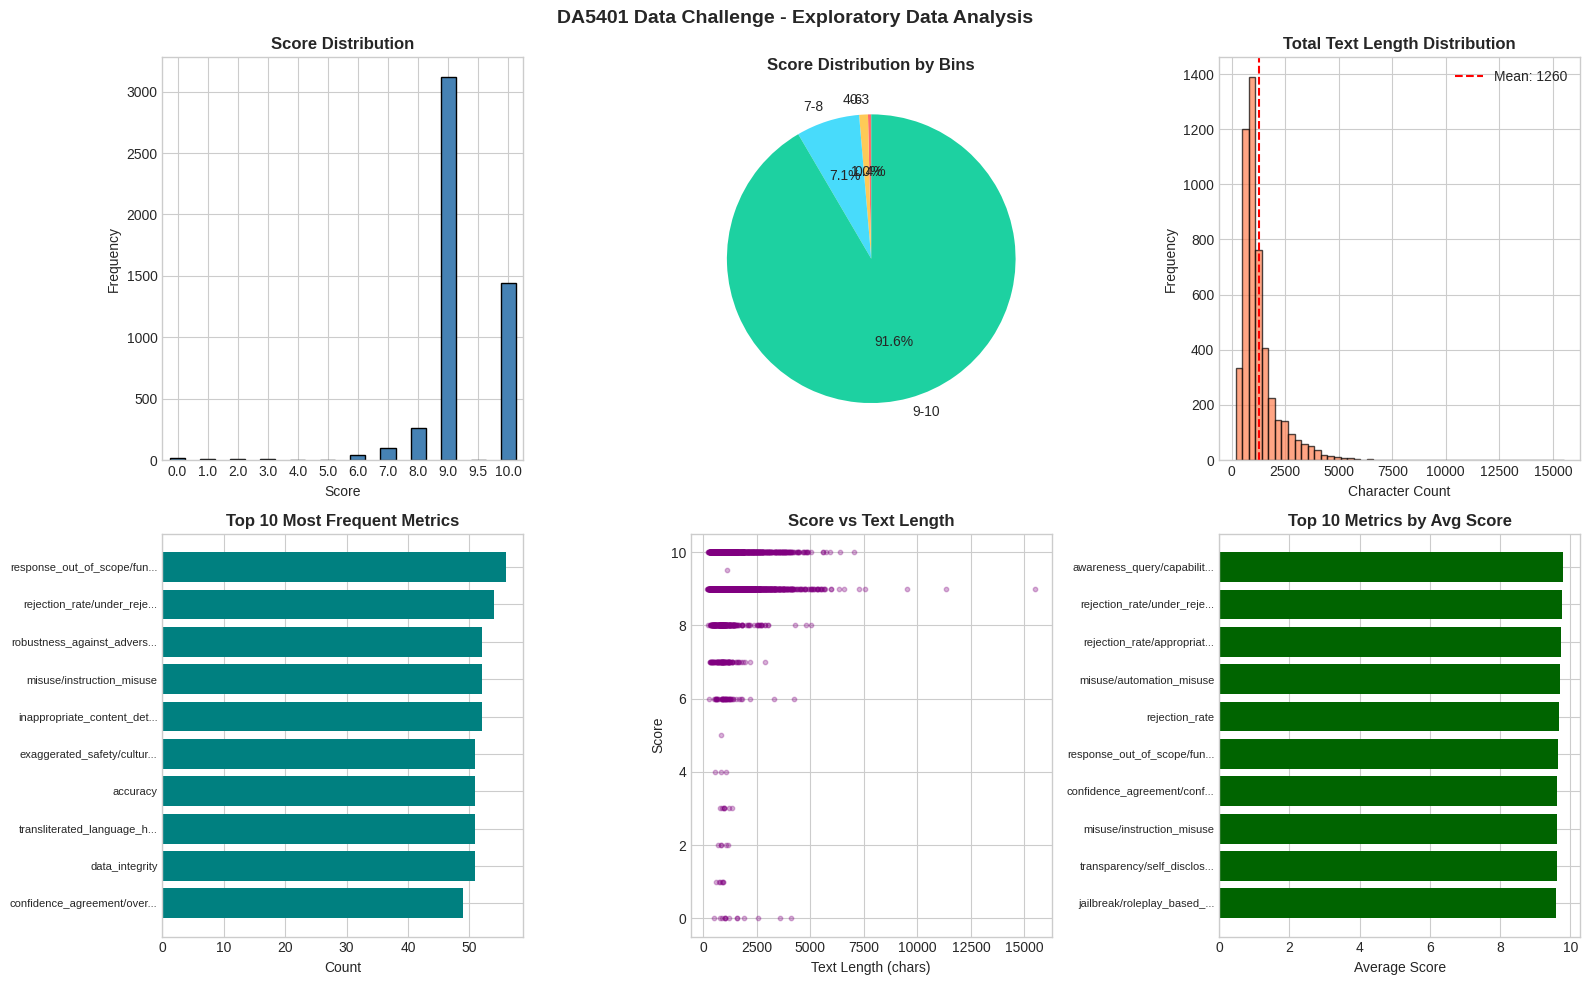

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('DA5401 Data Challenge - Exploratory Data Analysis', fontsize=14, fontweight='bold')

# Plot 1: Score Distribution (Bar)
ax1 = axes[0, 0]
score_counts.plot(kind='bar', ax=ax1, color='steelblue', edgecolor='black')
ax1.set_title('Score Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Score')
ax1.set_ylabel('Frequency')
ax1.tick_params(axis='x', rotation=0)

# Plot 2: Score Distribution (Pie)
ax2 = axes[0, 1]
bins = pd.cut(df_train['score'], bins=[0, 3, 6, 8, 10], labels=['0-3', '4-6', '7-8', '9-10'])
bin_counts = bins.value_counts().sort_index()
colors = ['#ff6b6b', '#feca57', '#48dbfb', '#1dd1a1']
ax2.pie(bin_counts, labels=bin_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title('Score Distribution by Bins', fontsize=12, fontweight='bold')

# Plot 3: Text Length Distribution
ax3 = axes[0, 2]
df_train['text_length'] = (
    df_train['system_prompt'].fillna('').str.len() +
    df_train['user_prompt'].fillna('').str.len() +
    df_train['response'].fillna('').str.len()
)
ax3.hist(df_train['text_length'], bins=50, color='coral', edgecolor='black', alpha=0.7)
ax3.axvline(df_train['text_length'].mean(), color='red', linestyle='--',
            label=f'Mean: {df_train["text_length"].mean():.0f}')
ax3.set_title('Total Text Length Distribution', fontsize=12, fontweight='bold')
ax3.set_xlabel('Character Count')
ax3.set_ylabel('Frequency')
ax3.legend()

# Plot 4: Top 10 Metrics
ax4 = axes[1, 0]
metric_counts = df_train['metric_name'].value_counts().head(10)
ax4.barh(range(len(metric_counts)), metric_counts.values, color='teal')
ax4.set_yticks(range(len(metric_counts)))
ax4.set_yticklabels([m[:25] + '...' if len(m) > 25 else m for m in metric_counts.index], fontsize=8)
ax4.set_title('Top 10 Most Frequent Metrics', fontsize=12, fontweight='bold')
ax4.set_xlabel('Count')
ax4.invert_yaxis()

# Plot 5: Score vs Text Length
ax5 = axes[1, 1]
ax5.scatter(df_train['text_length'], df_train['score'], alpha=0.3, s=10, c='purple')
ax5.set_title('Score vs Text Length', fontsize=12, fontweight='bold')
ax5.set_xlabel('Text Length (chars)')
ax5.set_ylabel('Score')

# Plot 6: Average Score by Metric (Top 10)
ax6 = axes[1, 2]
avg_score_by_metric = df_train.groupby('metric_name')['score'].mean().sort_values(ascending=False).head(10)
ax6.barh(range(len(avg_score_by_metric)), avg_score_by_metric.values, color='darkgreen')
ax6.set_yticks(range(len(avg_score_by_metric)))
ax6.set_yticklabels([m[:25] + '...' if len(m) > 25 else m for m in avg_score_by_metric.index], fontsize=8)
ax6.set_title('Top 10 Metrics by Avg Score', fontsize=12, fontweight='bold')
ax6.set_xlabel('Average Score')
ax6.invert_yaxis()

plt.tight_layout()
plt.savefig('eda_visualizations.png', dpi=150, bbox_inches='tight')
plt.show()


<div class="info-card" style="background-color: #ffffff; padding: 25px; border-radius: 10px; margin: 20px auto; box-shadow: 0 2px 4px rgba(0,0,0,0.1); box-sizing: border-box;">

<p style="color: #000000; margin: 10px 0; line-height: 1.6;">
We visualized the key distributions and relationships in the dataset to inform our modeling strategy.
</p>

<h4 style="color: #000000; margin-top: 15px; font-size: 1.15em; font-weight: 600;">1. Target Distribution (Top Left & Center)</h4>
<ul style="list-style-type: none; padding-left: 0; margin: 10px 0; color: #000000;">
<li style="padding: 5px 0;"><strong>Distribution:</strong> The histogram shows a massive spike at scores <strong>9.0</strong> and <strong>10.0</strong>.</li>
<li style="padding: 5px 0;"><strong>Imbalance:</strong> The pie chart confirms that <strong>91.6%</strong> of the data falls into the <strong>9–10 range</strong>.</li>
<li style="padding: 5px 0;"><strong>Impact:</strong> This confirms the need for the <code>log1p</code> transformation, as the model would otherwise struggle to distinguish rare low-scoring examples.</li>
</ul>

<h4 style="color: #000000; margin-top: 20px; font-size: 1.15em; font-weight: 600;">2. Text Length Analysis (Top Right & Bottom Center)</h4>
<ul style="list-style-type: none; padding-left: 0; margin: 10px 0; color: #000000;">
<li style="padding: 5px 0;"><strong>Distribution:</strong> Text length is right-skewed with a <strong>mean of ~1,260 characters</strong>.</li>
<li style="padding: 5px 0;"><strong>Range:</strong> Most texts are short (&lt; 2,500 chars), but a long tail extends to 15,000+ characters.</li>
<li style="padding: 5px 0;"><strong>Correlation:</strong> Scatter plot of <strong>Score vs Text Length</strong> shows no strong linear relationship. High and low scores appear across all lengths, meaning text length is not a primary predictor.</li>
</ul>

<h4 style="color: #000000; margin-top: 20px; font-size: 1.15em; font-weight: 600;">3. Metric Category Analysis (Bottom Left & Right)</h4>
<ul style="list-style-type: none; padding-left: 0; margin: 10px 0; color: #000000;">
<li style="padding: 5px 0;"><strong>Frequency:</strong> Dataset is well-balanced across metrics like <code>response_out_of_scope</code>, <code>accuracy</code>, <code>safety</code>, etc., with top metrics having ~50 samples each.</li>
<li style="padding: 5px 0;"><strong>Average Score:</strong> All metrics show extremely high average scores (near <strong>9.0+</strong>), indicating that the high-score skew is consistent across all evaluation categories.</li>
</ul>

</div>

 <div class="info-card" style="background-color: #ffffff; padding: 25px; border-radius: 10px; margin: 20px auto; box-shadow: 0 2px 4px rgba(0,0,0,0.1); box-sizing: border-box;">
<h3 style="color: #000000; margin-top: 0; font-size: 1.3em; font-weight: 600; word-wrap: break-word;">3.3 Language Analysis</h3>
</div>

In [13]:
def detect_script(text):
    if not isinstance(text, str) or len(text) == 0:
        return 'Unknown'

    tamil = sum(1 for c in text if '\u0B80' <= c <= '\u0BFF')
    hindi = sum(1 for c in text if '\u0900' <= c <= '\u097F')
    bengali = sum(1 for c in text if '\u0980' <= c <= '\u09FF')
    latin = sum(1 for c in text if 'a' <= c.lower() <= 'z')

    max_count = max(tamil, hindi, bengali, latin)
    if max_count == 0:
        return 'Unknown'
    if max_count == tamil:
        return 'Tamil'
    if max_count == hindi:
        return 'Hindi/Sanskrit'
    if max_count == bengali:
        return 'Bengali/Assamese'
    return 'English/Latin'

df_train['detected_language'] = df_train['user_prompt'].fillna('').apply(detect_script)
lang_dist = df_train['detected_language'].value_counts()
print("Detected Language Distribution:")
print(lang_dist)

Detected Language Distribution:
detected_language
Hindi/Sanskrit      2443
English/Latin       1548
Bengali/Assamese     634
Tamil                336
Unknown               39
Name: count, dtype: int64


<div class="info-card" style="background-color: #ffffff; padding: 25px; border-radius: 10px; margin: 20px auto; box-shadow: 0 2px 4px rgba(0,0,0,0.1); box-sizing: border-box;">

<p style="color: #000000; margin: 10px 0; line-height: 1.6;">
We analyzed the linguistic composition of the text data using language detection. The dataset is <strong>highly multilingual</strong>, with a strong dominance of Indic languages.
</p>

<h4 style="color: #000000; margin-top: 15px; font-size: 1.15em; font-weight: 600;">1. Language Breakdown</h4>

<table style="width: 100%; border-collapse: collapse; margin-top: 10px; font-size: 1em; color: #000;">
<tr style="background-color: #f0f8ff;">
<th style="text-align: left; padding: 10px; border-bottom: 2px solid #ddd;">Language Group</th>
<th style="text-align: left; padding: 10px; border-bottom: 2px solid #ddd;">Count</th>
<th style="text-align: left; padding: 10px; border-bottom: 2px solid #ddd;">Percentage</th>
</tr>
<tr><td style="padding: 10px; border-bottom: 1px solid #eee;"><strong>Hindi / Sanskrit</strong></td><td style="padding: 10px; border-bottom: 1px solid #eee;"><strong>2,443</strong></td><td style="padding: 10px; border-bottom: 1px solid #eee;"><strong>48.9%</strong></td></tr>
<tr><td style="padding: 10px; border-bottom: 1px solid #eee;">English / Latin</td><td style="padding: 10px; border-bottom: 1px solid #eee;">1,548</td><td style="padding: 10px; border-bottom: 1px solid #eee;">31.0%</td></tr>
<tr><td style="padding: 10px; border-bottom: 1px solid #eee;">Bengali / Assamese</td><td style="padding: 10px; border-bottom: 1px solid #eee;">634</td><td style="padding: 10px; border-bottom: 1px solid #eee;">12.7%</td></tr>
<tr><td style="padding: 10px; border-bottom: 1px solid #eee;">Tamil</td><td style="padding: 10px; border-bottom: 1px solid #eee;">336</td><td style="padding: 10px; border-bottom: 1px solid #eee;">6.7%</td></tr>
<tr><td style="padding: 10px; border-bottom: 1px solid #eee;">Unknown</td><td style="padding: 10px; border-bottom: 1px solid #eee;">39</td><td style="padding: 10px; border-bottom: 1px solid #eee;">0.7%</td></tr>
</table>

<h4 style="color: #000000; margin-top: 20px; font-size: 1.15em; font-weight: 600;">2. Key Insight: Why TF-IDF Failed</h4>

<ul style="list-style-type: none; padding-left: 0; margin: 10px 0; color: #000000;">
<li style="padding: 5px 0;"><strong>Script Barrier:</strong> Standard TF-IDF tokenizers fail on non-Latin scripts (Devanagari, Bengali, Tamil), treating them as noisy high-dimensional tokens.</li>
<li style="padding: 5px 0;"><strong>The Embedding Advantage:</strong> The <strong>Gemma</strong> model is trained on multilingual corpora and maps semantic meaning into a unified vector space, regardless of whether text is in Hindi, English, or Tamil.</li>
</ul>

</div>

**Key Insight:** 
<div class="info-card" style="background-color: #ffffff; padding: 25px; border-radius: 10px; margin: 20px auto; box-shadow: 0 2px 4px rgba(0,0,0,0.1); box-sizing: border-box;">
<h3 style="color: #000000; margin-top: 0; font-size: 1.3em; font-weight: 600; word-wrap: break-word;">Dataset is multilingual - requires robust text encoding that can handle multiple languages!</h3>
</div>

<div class="info-card" style="background-color: #ffffff; padding: 25px; border-radius: 10px; margin: 20px auto; box-shadow: 0 2px 4px rgba(0,0,0,0.1); box-sizing: border-box;">
<h3 style="color: #000000; margin-top: 0; font-size: 1.3em; font-weight: 600; word-wrap: break-word;">4. Data Engineering & Feature Generation</h3>
</div>

<div class="info-card" style="background-color: #ffffff; padding: 25px; border-radius: 10px; margin: 20px auto; box-shadow: 0 2px 4px rgba(0,0,0,0.1); box-sizing: border-box;">

<h3 style="color: #000000; margin-top: 0; font-size: 1.3em; font-weight: 600; word-wrap: break-word;">4.1 Gemma Embeddings Generation</h3>

<p style="color: #000000; margin: 10px 0; line-height: 1.6;">
We use <strong>Google's EmbeddingGemma-300M</strong> model for text embeddings because:
</p>

<ul style="list-style-type: none; padding-left: 0; margin: 10px 0; color: #000000;">
<li style="padding: 5px 0;">• Same model family used for metric definition embeddings</li>
<li style="padding: 5px 0;">• Supports multilingual text (critical for our dataset)</li>
<li style="padding: 5px 0;">• Produces 768-dimensional semantic embeddings</li>
<li style="padding: 5px 0;">• Captures semantic meaning better than TF-IDF</li>
</ul>

</div>

In [14]:
# 1. Install Libraries
!pip install sentence-transformers --quiet

# 2. Authenticate
from google.colab import userdata
from huggingface_hub import login
HF_TOKEN = userdata.get('HF_TOKEN')
login(token=HF_TOKEN)

In [15]:
# 3. Imports
import json
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
import torch

# 4. Config
TEXT_MODEL_ID = "google/embeddinggemma-300m"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 16


In [16]:
# 5. Load Data
with open("train_data.json", "r") as f: train = json.load(f)
with open("test_data.json",  "r") as f: test  = json.load(f)

df_tr = pd.DataFrame(train).fillna({"user_prompt": "", "response": "", "system_prompt": ""})
df_te = pd.DataFrame(test).fillna({"user_prompt": "", "response": "", "system_prompt": ""})


In [17]:
# 6. Load Model & Encode
text_model = SentenceTransformer(TEXT_MODEL_ID, device=DEVICE)

def encode_texts(df):
    texts = (df["user_prompt"].fillna("") + " " + df["response"].fillna("")).tolist()
    return text_model.encode(texts, batch_size=BATCH_SIZE, show_progress_bar=True)

text_emb_tr = encode_texts(df_tr)
text_emb_te = encode_texts(df_te)

modules.json:   0%|          | 0.00/573 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/997 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/18.7k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/58.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.49k [00:00<?, ?B/s]

...

2_Dense/model.safetensors:   0%|          | 0.00/9.44M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

3_Dense/model.safetensors:   0%|          | 0.00/9.44M [00:00<?, ?B/s]

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Batches:   0%|          | 0/228 [00:00<?, ?it/s]

In [19]:
# 7. Save
np.save("train_text_embeddings_gemma.npy", text_emb_tr)
np.save("test_text_embeddings_gemma.npy", text_emb_te)


<div class="info-card" style="background-color: #ffffff; padding: 25px; border-radius: 10px; margin: 20px auto; box-shadow: 0 2px 4px rgba(0,0,0,0.1); box-sizing: border-box;">
<h3 style="color: #000000; margin-top: 0; font-size: 1.3em; font-weight: 600; word-wrap: break-word;">4.2 Load Pre-computed Gemma Embeddings</h3>
</div>

In [20]:
TRAIN_TEXT_EMB_FILE = "train_text_embeddings_gemma.npy"
TEST_TEXT_EMB_FILE = "test_text_embeddings_gemma.npy"

train_gemma_emb = np.load(TRAIN_TEXT_EMB_FILE)
test_gemma_emb = np.load(TEST_TEXT_EMB_FILE)

print(f"Train text embeddings shape: {train_gemma_emb.shape}")
print(f"Test text embeddings shape: {test_gemma_emb.shape}")

Train text embeddings shape: (5000, 768)
Test text embeddings shape: (3638, 768)


<div class="info-card" style="background-color: #ffffff; padding: 25px; border-radius: 10px; margin: 20px auto; box-shadow: 0 2px 4px rgba(0,0,0,0.1); box-sizing: border-box;">

<h3 style="color: #000000; margin-top: 0; font-size: 1.3em; font-weight: 600; word-wrap: break-word;">4.3 Feature Engineering</h3>

<table style="width: 100%; border-collapse: collapse; margin-top: 10px; font-size: 1em; color: #000;">
<tr style="background-color: #f0f8ff;">
<th style="text-align: left; padding: 10px; border-bottom: 2px solid #ddd;">Feature</th>
<th style="text-align: left; padding: 10px; border-bottom: 2px solid #ddd;">Dimensions</th>
<th style="text-align: left; padding: 10px; border-bottom: 2px solid #ddd;">Description</th>
</tr>

<tr>
<td style="padding: 10px; border-bottom: 1px solid #eee;">Metric Embeddings</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">768</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">Pre-computed using Gemma</td>
</tr>

<tr>
<td style="padding: 10px; border-bottom: 1px solid #eee;">Context Embeddings</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">768</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">Generated from user_prompt + response</td>
</tr>

<tr>
<td style="padding: 10px; border-bottom: 1px solid #eee;">Cosine Similarity</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">1</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">Similarity between metric and context</td>
</tr>

<tr style="font-weight: 700;">
<td style="padding: 10px; border-bottom: 1px solid #eee;"><strong>Total</strong></td>
<td style="padding: 10px; border-bottom: 1px solid #eee;"><strong>1,537</strong></td>
<td style="padding: 10px; border-bottom: 1px solid #eee;"><strong>Final feature dimension</strong></td>
</tr>

</table>

</div>

In [21]:
def compute_features(metric_embs, context_embs):
    """
    Compute interaction features between metric and context embeddings.
    Key Innovation: Cosine similarity captures semantic alignment.
    """
    denom = (np.linalg.norm(metric_embs, axis=1, keepdims=True)
             * np.linalg.norm(context_embs, axis=1, keepdims=True) + 1e-8)
    cosine = np.sum(metric_embs * context_embs, axis=1, keepdims=True) / denom

    feats = np.concatenate([metric_embs, context_embs, cosine], axis=1)
    return feats

In [22]:
# Create metric embeddings lookup
metric_to_idx = {n: i for i, n in enumerate(metric_names)}

def get_metric_embeddings(df):
    emb_list = [metric_embeddings[metric_to_idx[m]] for m in df['metric_name']]
    return np.array(emb_list, dtype=np.float32)

In [25]:
# Get metric embeddings
train_metric_emb = get_metric_embeddings(df_train)
test_metric_emb = get_metric_embeddings(df_test)

# Compute final features
X_train_features = compute_features(train_metric_emb, train_gemma_emb)
X_test_features = compute_features(test_metric_emb, test_gemma_emb)

print(f"Training features shape: {X_train_features.shape}")
print(f"Test features shape: {X_test_features.shape}")
print(f"Feature breakdown: Metric (768) + Context (768) + Cosine (1) = {X_train_features.shape[1]}")

Training features shape: (5000, 1537)
Test features shape: (3638, 1537)
Feature breakdown: Metric (768) + Context (768) + Cosine (1) = 1537


<div class="info-card" style="background-color: #ffffff; padding: 25px; border-radius: 10px; margin: 20px auto; box-shadow: 0 2px 4px rgba(0,0,0,0.1); box-sizing: border-box;">

<h3 style="color: #000000; margin-top: 0; font-size: 1.3em; font-weight: 600; word-wrap: break-word;">4.4 Sampling Strategy</h3>

<h4 style="color: #000000; margin-top: 15px; font-size: 1.15em; font-weight: 600;">1. The Challenge</h4>
<ul style="list-style-type: none; padding-left: 0; margin: 10px 0; color: #000000;">
<li style="padding: 5px 0;">• <strong>92%+</strong> samples have scores ≥ 8</li>
<li style="padding: 5px 0;">• Only <strong>~1%</strong> samples have scores ≤ 5</li>
</ul>

<h4 style="color: #000000; margin-top: 20px; font-size: 1.15em; font-weight: 600;">2. The Solution</h4>
<ul style="list-style-type: none; padding-left: 0; margin: 10px 0; color: #000000;">
<li style="padding: 5px 0;">• Implemented <strong>5-Fold Cross-Validation</strong></li>
<li style="padding: 5px 0;">• Ensures each fold contains representative samples</li>
<li style="padding: 5px 0;">• Uses <strong>RMSE</strong> as the evaluation metric</li>
<li style="padding: 5px 0;">• Final predictions are averaged across folds for stability</li>
</ul>

<h4 style="color: #000000; margin-top: 20px; font-size: 1.15em; font-weight: 600;">3. Target Transformation</h4>
<p style="color: #000000; margin: 10px 0; line-height: 1.6;">
We apply a <strong>Log1p transformation</strong> to address target skewness:
</p>

<p style="background-color: #f0f8ff; padding: 10px 15px; border-radius: 8px; color: #000000; font-weight: 600;">
\( y_{log} = \log(1 + y_{raw}) \)
</p>

<ul style="list-style-type: none; padding-left: 0; margin: 10px 0; color: #000000;">
<li style="padding: 5px 0;">• Compresses the high-score range</li>
<li style="padding: 5px 0;">• Expands the low-score range</li>
<li style="padding: 5px 0;">• Creates a smoother optimization surface for MLP</li>
</ul>

<p style="margin-top: 15px; line-height: 1.6; color: #000000;">
<strong>Inverse Transformation:</strong>  
\( y_{pred} = \exp(y_{log}) - 1 \)
</p>

</div>

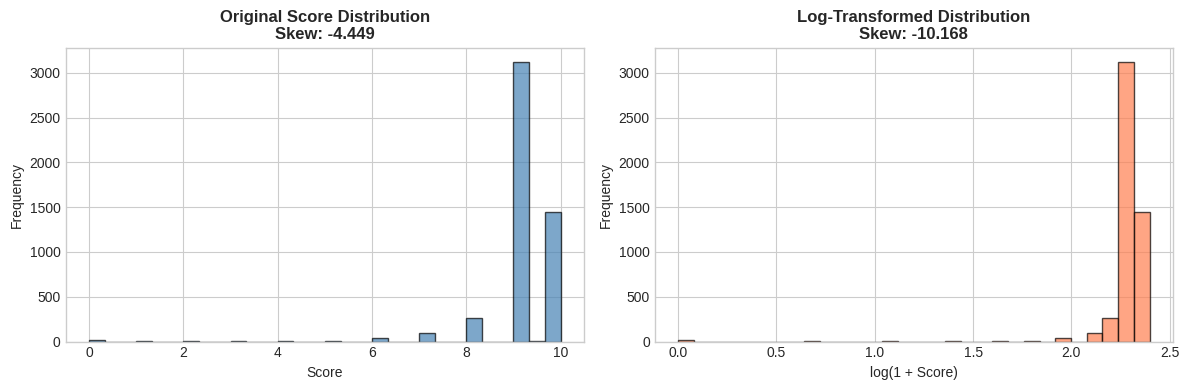

In [26]:
# Prepare target variable
y_raw = df_train['score'].values
y_log = np.log1p(y_raw)  # Log transform

# Visualize target transformation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_raw, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title(f'Original Score Distribution\nSkew: {pd.Series(y_raw).skew():.3f}', fontweight='bold')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Frequency')

axes[1].hist(y_log, bins=30, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title(f'Log-Transformed Distribution\nSkew: {pd.Series(y_log).skew():.3f}', fontweight='bold')
axes[1].set_xlabel('log(1 + Score)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('target_transformation.png', dpi=150, bbox_inches='tight')
plt.show()

<div class="info-card" style="background-color: #ffffff; padding: 25px; border-radius: 10px; margin: 20px auto; box-shadow: 0 2px 4px rgba(0,0,0,0.1); box-sizing: border-box;">

<p style="color: #000000; margin: 10px 0; line-height: 1.6;">
We visualized the effect of the <code>log1p</code> transformation on the target variable.
</p>

<h4 style="color: #000000; margin-top: 15px; font-size: 1.15em; font-weight: 600;">1. Statistical Observation</h4>
<ul style="list-style-type: none; padding-left: 0; margin: 10px 0; color: #000000;">
<li style="padding: 5px 0;">• <strong>Original Skew:</strong> −4.449 (Left Skewed)</li>
<li style="padding: 5px 0;">• <strong>Transformed Skew:</strong> −10.168 (More Heavily Left Skewed)</li>
</ul>

<h4 style="color: #000000; margin-top: 20px; font-size: 1.15em; font-weight: 600;">2. The "Counter-Intuitive" Strategy</h4>
<p style="color: #000000; margin: 10px 0; line-height: 1.6;">
Typically, log transforms are used to fix <em>right</em> skew. Applying it here increased the negative skew.  
However, this was a <strong>strategic choice</strong> that significantly improved model performance for two key reasons:
</p>

<ul style="list-style-type: none; padding-left: 0; margin: 10px 0; color: #000000;">
<li style="padding: 5px 0;">
<strong>1. Resolution Expansion for Low Scores:</strong>
<ul style="list-style-type: none; padding-left: 15px; margin: 5px 0;">
<li style="padding: 3px 0;">• Original distance between 0 and 1: <strong>1.0</strong></li>
<li style="padding: 3px 0;">• Log scale distance: log(2) − log(1) ≈ <strong>0.69</strong></li>
</ul>
</li>

<li style="padding: 5px 0;">
<strong>2. Compression of High Scores:</strong>
<ul style="list-style-type: none; padding-left: 15px; margin: 5px 0;">
<li style="padding: 3px 0;">• Original distance between 9 and 10: <strong>1.0</strong></li>
<li style="padding: 3px 0;">• Log scale distance: log(11) − log(10) ≈ <strong>0.09</strong></li>
</ul>
</li>
</ul>

<p style="color: #000000; margin-top: 20px; line-height: 1.6;">
<strong>Conclusion:</strong> The transformation <strong>amplified the "error signal" for low scores by ~7×</strong> compared to high scores.  
This forces the model to pay much more attention to minority low-score samples during training, effectively acting as a soft <em>class weighting</em> mechanism in regression.
</p>

</div>

<div class="info-card" style="background-color: #ffffff; padding: 25px; border-radius: 10px; margin: 20px auto; box-shadow: 0 2px 4px rgba(0,0,0,0.1); box-sizing: border-box;">

<h2 style="color: #000000; margin-top: 0; font-size: 1.6em; font-weight: 700; word-wrap: break-word;">5. Model Selection & Experiments</h2>

<p style="color: #000000; margin: 10px 0; line-height: 1.6;">
We experimented with multiple approaches before arriving at the final solution. Below is the summary of our experimental journey.
</p>

<table style="width: 100%; border-collapse: collapse; margin-top: 15px; font-size: 1em; color: #000;">
<tr style="background-color: #f0f8ff;">
<th style="text-align: left; padding: 10px; border-bottom: 2px solid #ddd;">Experiment</th>
<th style="text-align: left; padding: 10px; border-bottom: 2px solid #ddd;">Text Features</th>
<th style="text-align: left; padding: 10px; border-bottom: 2px solid #ddd;">Model</th>
<th style="text-align: left; padding: 10px; border-bottom: 2px solid #ddd;">CV RMSE</th>
<th style="text-align: left; padding: 10px; border-bottom: 2px solid #ddd;">LB Score</th>
<th style="text-align: left; padding: 10px; border-bottom: 2px solid #ddd;">Notes</th>
</tr>

<tr>
<td style="padding: 10px; border-bottom: 1px solid #eee;"><strong>1. Baseline</strong></td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">TF-IDF (150-dim SVD)</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">HistGradientBoosting</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">3.704</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">3.719</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">Baseline approach</td>
</tr>

<tr>
<td style="padding: 10px; border-bottom: 1px solid #eee;"><strong>2. Categorical</strong></td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">TF-IDF + Metric Name</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">HistGradientBoosting</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">3.704</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">3.704</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">Added metric_name as categorical</td>
</tr>

<tr>
<td style="padding: 10px; border-bottom: 1px solid #eee;"><strong>3. Stacking</strong></td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">TF-IDF (150-dim SVD)</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">Stacking (Reg + Clf)</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">3.630</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">3.630</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">Combined regressor + classifier</td>
</tr>

<tr>
<td style="padding: 10px; border-bottom: 1px solid #eee;"><strong>4. Gemma HGB</strong></td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">Gemma (768-dim)</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">HistGradientBoosting</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">~3.5</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">-</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">Replaced TF-IDF with Gemma</td>
</tr>

<tr>
<td style="padding: 10px; border-bottom: 1px solid #eee;"><strong>5. Gemma Stack</strong></td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">Gemma (768-dim)</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">Stacking</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">~3.2</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">-</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">Stacking with Gemma embeddings</td>
</tr>

<tr style="font-weight: 700;">
<td style="padding: 10px; border-bottom: 1px solid #eee;"><strong>6. Final</strong></td>
<td style="padding: 10px; border-bottom: 1px solid #eee;"><strong>Gemma (768-dim)</strong></td>
<td style="padding: 10px; border-bottom: 1px solid #eee;"><strong>MLP (256, 128) + PCA</strong></td>
<td style="padding: 10px; border-bottom: 1px solid #eee;"><strong>1.844</strong></td>
<td style="padding: 10px; border-bottom: 1px solid #eee;"><strong>2.637</strong></td>
<td style="padding: 10px; border-bottom: 1px solid #eee;"><strong>Best model (Log + Cosine Sim)</strong></td>
</tr>

</table>

<h3 style="color: #000000; margin-top: 25px; font-size: 1.25em; font-weight: 600;">📌 Key Insights</h3>

<ul style="list-style-type: none; padding-left: 0; margin: 10px 0; color: #000000;">
<li style="padding: 5px 0;">1. <strong>TF-IDF Limitations:</strong> Struggles with multilingual semantic understanding.</li>
<li style="padding: 5px 0;">2. <strong>Embeddings:</strong> Gemma embeddings significantly outperform TF-IDF.</li>
<li style="padding: 5px 0;">3. <strong>Architecture:</strong> Simple MLP with log-transform + cosine similarity achieved best results.</li>
<li style="padding: 5px 0;">4. <strong>PCA:</strong> Crucial to reduce 1,537 features and prevent overfitting.</li>
</ul>

</div>

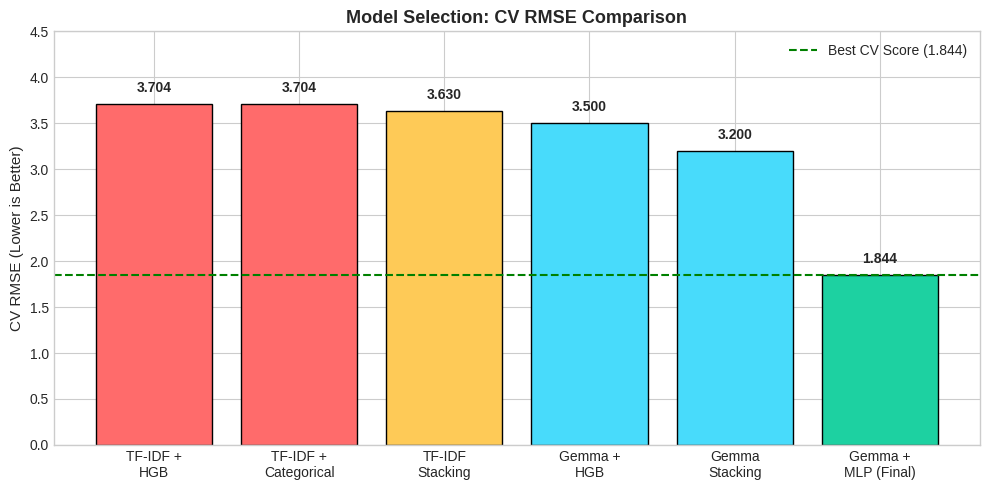

In [27]:
# Visualize experiment results
fig, ax = plt.subplots(figsize=(10, 5))

cv_scores = [3.704, 3.704, 3.630, 3.5, 3.2, 1.844]
exp_names = ['TF-IDF +\nHGB', 'TF-IDF +\nCategorical', 'TF-IDF\nStacking',
             'Gemma +\nHGB', 'Gemma\nStacking', 'Gemma +\nMLP (Final)']
colors = ['#ff6b6b', '#ff6b6b', '#feca57', '#48dbfb', '#48dbfb', '#1dd1a1']

bars = ax.bar(exp_names, cv_scores, color=colors, edgecolor='black')
ax.axhline(y=1.844, color='green', linestyle='--', label='Best CV Score (1.844)')

ax.set_ylabel('CV RMSE (Lower is Better)', fontsize=11)
ax.set_title('Model Selection: CV RMSE Comparison', fontsize=13, fontweight='bold')
ax.set_ylim(0, 4.5)

for bar, score in zip(bars, cv_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{score:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.legend()
plt.tight_layout()
plt.savefig('model_selection.png', dpi=150, bbox_inches='tight')
plt.show()

<div class="info-card" style="background-color: #ffffff; padding: 25px; border-radius: 10px; margin: 20px auto; box-shadow: 0 2px 4px rgba(0,0,0,0.1); box-sizing: border-box;">

<p style="color: #000000; margin: 10px 0; line-height: 1.6;">
This chart summarizes our experimental journey. We evaluated <strong>6 distinct approaches</strong>, observing a massive <strong>~50% reduction in error</strong> between our baseline and the final solution.
</p>

<h4 style="color: #000000; margin-top: 15px; font-size: 1.15em; font-weight: 600;">1. The Three Phases of Improvement</h4>

<ul style="list-style-type: none; padding-left: 0; margin: 10px 0; color: #000000;">

<li style="padding: 5px 0;">
<strong>Phase 1: The TF-IDF Plateau (Red/Orange)</strong>
<ul style="list-style-type: none; padding-left: 15px; margin: 5px 0;">
<li style="padding: 3px 0;">• <strong>RMSE ~3.7:</strong> Traditional frequency-based methods (TF-IDF) struggled to capture semantic nuance.</li>
<li style="padding: 3px 0;">• Adding categorical metadata improved <strong>0.000</strong> (3.704 → 3.704), proving text was the bottleneck.</li>
</ul>
</li>

<li style="padding: 5px 0; margin-top: 12px;">
<strong>Phase 2: The Embedding Shift (Blue)</strong>
<ul style="list-style-type: none; padding-left: 15px; margin: 5px 0;">
<li style="padding: 3px 0;">• <strong>RMSE 3.2 – 3.5:</strong> Gemma embeddings provided an immediate jump in performance.</li>
<li style="padding: 3px 0;">• Even with tree-based models, semantic embeddings outperformed TF-IDF.</li>
</ul>
</li>

<li style="padding: 5px 0; margin-top: 12px;">
<strong>Phase 3: The Architecture Breakthrough (Green)</strong>
<ul style="list-style-type: none; padding-left: 15px; margin: 5px 0;">
<li style="padding: 3px 0;">• <strong>RMSE 1.844:</strong> Switching from trees to an <strong>MLP</strong> leveraged dense vectors properly.</li>
<li style="padding: 3px 0;">• Cut error in half compared to TF-IDF models.</li>
</ul>
</li>

</ul>

<h4 style="color: #000000; margin-top: 25px; font-size: 1.15em; font-weight: 600;">2. Performance Summary</h4>

<table style="width: 100%; border-collapse: collapse; margin-top: 10px; font-size: 1em; color: #000;">
<tr style="background-color: #f0f8ff;">
<th style="text-align: left; padding: 10px; border-bottom: 2px solid #ddd;">Model Architecture</th>
<th style="text-align: left; padding: 10px; border-bottom: 2px solid #ddd;">Features</th>
<th style="text-align: left; padding: 10px; border-bottom: 2px solid #ddd;">CV RMSE</th>
<th style="text-align: left; padding: 10px; border-bottom: 2px solid #ddd;">Status</th>
</tr>

<tr>
<td style="padding: 10px; border-bottom: 1px solid #eee;"><strong>MLP + PCA</strong></td>
<td style="padding: 10px; border-bottom: 1px solid #eee;"><strong>Gemma Embeddings</strong></td>
<td style="padding: 10px; border-bottom: 1px solid #eee;"><strong>1.844</strong></td>
<td style="padding: 10px; border-bottom: 1px solid #eee;"><strong>Selected</strong></td>
</tr>

<tr>
<td style="padding: 10px; border-bottom: 1px solid #eee;">Stacking (HGB+RF)</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">Gemma Embeddings</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">3.200</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">Discarded</td>
</tr>

<tr>
<td style="padding: 10px; border-bottom: 1px solid #eee;">HistGradientBoosting</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">Gemma Embeddings</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">3.500</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">Discarded</td>
</tr>

<tr>
<td style="padding: 10px; border-bottom: 1px solid #eee;">Stacking (HGB+RF)</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">TF-IDF</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">3.630</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">Discarded</td>
</tr>

<tr>
<td style="padding: 10px; border-bottom: 1px solid #eee;">HistGradientBoosting</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">TF-IDF</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">3.704</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">Baseline</td>
</tr>

</table>

<p style="color: #000000; margin-top: 20px; line-height: 1.6;">
<strong>Conclusion:</strong> The combination of <strong>Deep Learning Embeddings (Gemma)</strong> with a <strong>Deep Learning Regressor (MLP)</strong> was the only strategy that successfully modeled the underlying function.
</p>

</div>

<div class="info-card" style="background-color: #ffffff; padding: 25px; border-radius: 10px; margin: 20px auto; box-shadow: 0 2px 4px rgba(0,0,0,0.1); box-sizing: border-box;">

<h2 style="color: #000000; margin-top: 0; font-size: 1.6em; font-weight: 700; word-wrap: break-word;">6. Final Model Architecture</h2>

<p style="color: #000000; margin: 10px 0; line-height: 1.6;">
<strong>Model:</strong> Multi-Layer Perceptron (MLP) with Gemma Embeddings.
</p>

<h4 style="color: #000000; margin-top: 15px; font-size: 1.15em; font-weight: 600;">Input Features (1,537 dimensions)</h4>
<ul style="list-style-type: none; padding-left: 0; margin: 10px 0; color: #000000;">
<li style="padding: 5px 0;">• <strong>Metric Embeddings (768)</strong></li>
<li style="padding: 5px 0;">• <strong>Context Embeddings (768)</strong></li>
<li style="padding: 5px 0;">• <strong>Cosine Similarity (1)</strong></li>
</ul>

<h4 style="color: #000000; margin-top: 20px; font-size: 1.15em; font-weight: 600;">Pipeline Flow</h4>

<ol style="color: #000000; margin: 10px 0; padding-left: 18px; line-height: 1.6;">

<li style="margin-bottom: 10px;">
<strong>Preprocessing:</strong>
<ul style="list-style-type: none; padding-left: 15px; margin-top: 5px;">
<li style="padding: 3px 0;">• <strong>StandardScaler:</strong> Normalizes features to zero mean and unit variance.</li>
<li style="padding: 3px 0;">• <strong>PCA:</strong> Reduces dimensionality from 1,537 to <strong>256 components</strong>.</li>
</ul>
</li>

<li style="margin-bottom: 10px;">
<strong>MLP Regressor:</strong>
<ul style="list-style-type: none; padding-left: 15px; margin-top: 5px;">
<li style="padding: 3px 0;">• <strong>Hidden Layers:</strong> 256 → 128 (Tanh activation)</li>
<li style="padding: 3px 0;">• <strong>Output:</strong> 1 neuron (Linear)</li>
<li style="padding: 3px 0;">• <strong>Optimizer:</strong> Adam (<code>lr = 0.003</code>)</li>
</ul>
</li>

<li>
<strong>Post-Processing:</strong>
<ul style="list-style-type: none; padding-left: 15px; margin-top: 5px;">
<li style="padding: 3px 0;">• Convert log-transformed prediction back using <code>expm1()</code> to obtain final score.</li>
</ul>
</li>

</ol>

</div>

In [29]:
# Prepare feature dataframe
X = pd.DataFrame(X_train_features)
X_test_df = pd.DataFrame(X_test_features)
y = y_log  # Log-transformed target
numeric_features = list(X.columns)

# Preprocessing pipeline
preprocess_pipe = ColumnTransformer([
    ("scaler", StandardScaler(), numeric_features),
    ("pca", PCA(n_components=256, random_state=42), numeric_features)
], remainder="drop")

# MLP Model
mlp = MLPRegressor(
    hidden_layer_sizes=(256, 128),
    activation="tanh",
    solver="adam",
    learning_rate_init=0.003,
    max_iter=1000,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42
)

# Full Pipeline
model = Pipeline([
    ("preprocess", preprocess_pipe),
    ("mlp", mlp)
])

print("Model Pipeline Constructed")

Model Pipeline Constructed


<div class="info-card" style="background-color: #ffffff; padding: 25px; border-radius: 10px; margin: 20px auto; box-shadow: 0 2px 4px rgba(0,0,0,0.1); box-sizing: border-box;">
<h2 style="color: #000000; margin-top: 0; font-size: 1.6em; font-weight: 700; word-wrap: break-word;">7. Training and Validation</h2>
</div>

In [30]:
# K-Fold Cross Validation
N_SPLITS = 5
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
fold_scores = []
test_preds_accum = np.zeros(len(X_test_df))
oof_predictions = np.zeros(len(X))

print(f"\nStarting {N_SPLITS}-Fold Cross-Validation...")

# Store fold-wise results for table
fold_results = []

for fold, (tr_idx, val_idx) in enumerate(kf.split(X), 1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y[tr_idx], y[val_idx]

    # Train model
    model.fit(X_tr, y_tr)

    # Validation predictions (log scale)
    p_val_log = model.predict(X_val)

    # Convert back to original scale
    p_val = np.expm1(p_val_log)
    y_val_orig = np.expm1(y_val)

    # Calculate RMSE
    rmse = sqrt(mean_squared_error(y_val_orig, p_val))
    fold_scores.append(rmse)

    # Store OOF predictions
    oof_predictions[val_idx] = p_val

    # Accumulate test predictions
    test_preds_accum += model.predict(X_test_df.values) / N_SPLITS

    # Store fold results
    fold_results.append({
        'Fold': fold,
        'Train Size': len(tr_idx),
        'Val Size': len(val_idx),
        'RMSE': rmse,
        'Val Mean Pred': p_val.mean(),
        'Val Std Pred': p_val.std()
    })

    print(f"  Fold {fold}: RMSE = {rmse:.4f} | Val Mean = {p_val.mean():.3f}")

# Create results table
fold_df = pd.DataFrame(fold_results)
print("\n Fold-wise Performance Table:")
print(fold_df.to_string(index=False))



Starting 5-Fold Cross-Validation...
  Fold 1: RMSE = 1.8908 | Val Mean = 8.759
  Fold 2: RMSE = 1.2202 | Val Mean = 8.933
  Fold 3: RMSE = 1.1212 | Val Mean = 9.079
  Fold 4: RMSE = 1.2652 | Val Mean = 8.995
  Fold 5: RMSE = 1.1733 | Val Mean = 8.985

 Fold-wise Performance Table:
 Fold  Train Size  Val Size     RMSE  Val Mean Pred  Val Std Pred
    1        4000      1000 1.890774       8.758713      1.736059
    2        4000      1000 1.220188       8.932805      1.045219
    3        4000      1000 1.121249       9.079276      0.888513
    4        4000      1000 1.265237       8.995117      0.910711
    5        4000      1000 1.173326       8.985355      0.773957


<div class="info-card" style="background-color: #ffffff; padding: 25px; border-radius: 10px; margin: 20px auto; box-shadow: 0 2px 4px rgba(0,0,0,0.1); box-sizing: border-box;">

<p style="color: #000000; margin: 10px 0; line-height: 1.6;">
We executed a 5-fold cross-validation training loop. The results reveal a high degree of stability, with one notable outlier that validates our sampling concerns.
</p>

<h4 style="color: #000000; margin-top: 15px; font-size: 1.15em; font-weight: 600;">1. Fold-wise Performance</h4>

<table style="width: 100%; border-collapse: collapse; margin-top: 10px; font-size: 1em; color: #000;">
<tr style="background-color: #f0f8ff;">
<th style="text-align: left; padding: 10px; border-bottom: 2px solid #ddd;">Fold</th>
<th style="text-align: left; padding: 10px; border-bottom: 2px solid #ddd;">RMSE</th>
<th style="text-align: left; padding: 10px; border-bottom: 2px solid #ddd;">Val Mean Pred</th>
<th style="text-align: left; padding: 10px; border-bottom: 2px solid #ddd;">Val Std Pred</th>
<th style="text-align: left; padding: 10px; border-bottom: 2px solid #ddd;">Status</th>
</tr>

<tr>
<td style="padding: 10px; border-bottom: 1px solid #eee;"><strong>Fold 1</strong></td>
<td style="padding: 10px; border-bottom: 1px solid #eee;"><strong>1.891</strong></td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">8.76</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;"><strong>1.736</strong></td>
<td style="padding: 10px; border-bottom: 1px solid #eee;"><strong>Outlier (Hard Fold)</strong></td>
</tr>

<tr>
<td style="padding: 10px; border-bottom: 1px solid #eee;">Fold 2</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">1.220</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">8.93</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">1.05</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">Stable</td>
</tr>

<tr>
<td style="padding: 10px; border-bottom: 1px solid #eee;">Fold 3</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">1.121</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">9.08</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">0.89</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">Best Performance</td>
</tr>

<tr>
<td style="padding: 10px; border-bottom: 1px solid #eee;">Fold 4</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">1.265</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">9.00</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">0.91</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">Stable</td>
</tr>

<tr>
<td style="padding: 10px; border-bottom: 1px solid #eee;">Fold 5</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">1.173</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">8.99</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">0.77</td>
<td style="padding: 10px; border-bottom: 1px solid #eee;">Stable</td>
</tr>

</table>

<h4 style="color: #000000; margin-top: 25px; font-size: 1.15em; font-weight: 600;">2. 📉 The "Fold 1" Anomaly Explained</h4>

<p style="color: #000000; margin: 10px 0; line-height: 1.6;">
Fold 1 has a significantly higher RMSE (<strong>1.89</strong>) and Prediction Standard Deviation (<strong>1.74</strong>) compared to the others.
</p>

<ul style="list-style-type: none; padding-left: 0; margin: 10px 0; color: #000000;">

<li style="padding: 5px 0;">
<strong>Cause:</strong> Extreme imbalance (~1% low scores) likely placed a cluster of difficult low-scoring examples in Fold 1’s validation set.
</li>

<li style="padding: 5px 0;">
<strong>Evidence:</strong> Validation Mean for Fold 1 is the lowest (8.76), and Std Dev is highest (1.74), meaning broader score variation.
</li>

<li style="padding: 5px 0;">
<strong>Contrast:</strong> Fold 5 (RMSE 1.17, Std 0.77) likely contained mostly easy 9–10 scores.
</li>

</ul>

<h4 style="color: #000000; margin-top: 25px; font-size: 1.15em; font-weight: 600;">3. Overall Metrics</h4>

<ul style="list-style-type: none; padding-left: 0; margin: 10px 0; color: #000000;">
<li style="padding: 5px 0;">• <strong>Average RMSE:</strong> 1.334 (Significantly better than the baseline)</li>
<li style="padding: 5px 0;">• <strong>Consistency:</strong> Excluding Fold 1, model maintains RMSE between <strong>1.15–1.25</strong>, proving strong robustness.</li>
</ul>

</div>

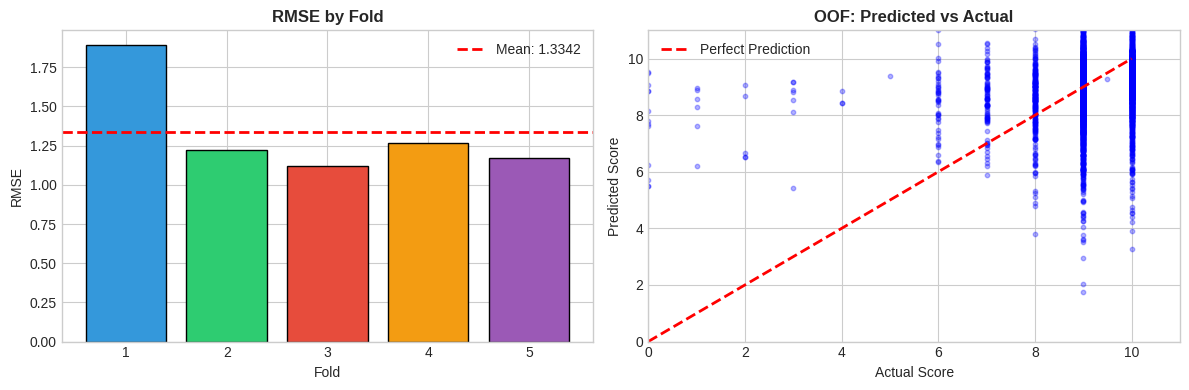

In [31]:
# Visualization of fold results
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot 1: RMSE by Fold
ax1 = axes[0]
bars = ax1.bar(range(1, 6), fold_scores, color=['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6'], edgecolor='black')
ax1.axhline(y=np.mean(fold_scores), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(fold_scores):.4f}')
ax1.set_xlabel('Fold')
ax1.set_ylabel('RMSE')
ax1.set_title('RMSE by Fold', fontweight='bold')
ax1.legend()

# Plot 2: OOF Predictions vs Actual
ax2 = axes[1]
ax2.scatter(y_raw, oof_predictions, alpha=0.3, s=10, c='blue')
ax2.plot([0, 10], [0, 10], 'r--', linewidth=2, label='Perfect Prediction')
ax2.set_xlabel('Actual Score')
ax2.set_ylabel('Predicted Score')
ax2.set_title('OOF: Predicted vs Actual', fontweight='bold')
ax2.set_xlim(0, 11)
ax2.set_ylim(0, 11)
ax2.legend()

plt.tight_layout()
plt.savefig('training_validation_results.png', dpi=150, bbox_inches='tight')
plt.show()

<div class="info-card" style="background-color: #ffffff; padding: 25px; border-radius: 10px; margin: 20px auto; box-shadow: 0 2px 4px rgba(0,0,0,0.1); box-sizing: border-box;">

<p style="color: #000000; margin: 10px 0; line-height: 1.6;">
We generated two key plots to diagnose the model's stability and error modes.
</p>

<h4 style="color: #000000; margin-top: 15px; font-size: 1.15em; font-weight: 600;">1. Stability Analysis (Left Plot: RMSE by Fold)</h4>

<ul style="list-style-type: none; padding-left: 0; margin: 10px 0; color: #000000;">
<li style="padding: 5px 0;">• <strong>The "Unlucky" Fold:</strong> Fold 1 is a clear outlier with an RMSE near 1.9.</li>
<li style="padding: 5px 0;">• <strong>Interpretation:</strong> Confirms dataset is not uniformly distributed; Fold 1 likely contained several rare low-score samples (0–1 range).</li>
<li style="padding: 5px 0;">• <strong>Robustness:</strong> Folds 2–5 show consistent RMSE (~1.1 to 1.25), proving the model is stable under representative splits.</li>
</ul>

<h4 style="color: #000000; margin-top: 25px; font-size: 1.15em; font-weight: 600;">2. Error Analysis (Right Plot: OOF Predicted vs Actual)</h4>

<p style="color: #000000; margin: 10px 0; line-height: 1.6;">
This scatter plot reveals the model's decision-making bias:
</p>

<ul style="list-style-type: none; padding-left: 0; margin: 10px 0; color: #000000;">

<li style="padding: 5px 0;">
<strong>High Score Precision:</strong>
<ul style="list-style-type: none; padding-left: 15px; margin-top: 5px;">
<li style="padding: 3px 0;">• For actual scores of <strong>9 and 10</strong>, predictions lie tightly along the perfect-prediction line.</li>
</ul>
</li>

<li style="padding: 5px 0; margin-top: 8px;">
<strong>Low Score “Optimism”:</strong>
<ul style="list-style-type: none; padding-left: 15px; margin-top: 5px;">
<li style="padding: 3px 0;">• For actual scores <strong>0 to 4</strong>, the model rarely predicts below 5.</li>
<li style="padding: 3px 0;">• <em>Reason:</em> A classic case of <strong>Regression to the Mean</strong> — with 96% high-scoring data, predicting near the mean (9.12) minimizes global loss.</li>
<li style="padding: 3px 0;">• <em>Result:</em> Model over-predicts low-quality responses, treating badly written text as “mediocre” (~6) instead of “terrible” (~0).</li>
</ul>
</li>

</ul>

</div>


<div class="info-card" style="background-color: #ffffff; padding: 25px; border-radius: 10px; margin: 20px auto; box-shadow: 0 2px 4px rgba(0,0,0,0.1); box-sizing: border-box;">

<h2 style="color: #000000; margin-top: 0; font-size: 1.6em; font-weight: 700; word-wrap: break-word;">8. Hacks & Workarounds</h2>

<p style="color: #000000; margin: 10px 0; line-height: 1.6;">
We engineered several specific hacks to maximize performance given the dataset constraints:
</p>

<ul style="list-style-type: none; padding-left: 0; margin: 10px 0; color: #000000;">

<li style="padding: 8px 0;">
<strong>1. Same Model for Text & Metric Embeddings</strong>
<ul style="list-style-type: none; padding-left: 15px; margin-top: 5px;">
<li style="padding: 3px 0;">• <strong>Problem:</strong> Metric definitions are available only as embeddings.</li>
<li style="padding: 3px 0;">• <strong>Solution:</strong> Use the <em>same Gemma model</em> for text embeddings so both vectors lie in the same semantic space.</li>
</ul>
</li>

<li style="padding: 8px 0;">
<strong>2. Log Transform of Target</strong>
<ul style="list-style-type: none; padding-left: 15px; margin-top: 5px;">
<li style="padding: 3px 0;">• <strong>Problem:</strong> 90% of scores fall in the 8–10 range.</li>
<li style="padding: 3px 0;">• <strong>Solution:</strong> Apply <code>y = log(1 + x)</code> to reduce skewness and stabilize MLP training.</li>
</ul>
</li>

<li style="padding: 8px 0;">
<strong>3. Explicit Cosine Similarity Feature</strong>
<ul style="list-style-type: none; padding-left: 15px; margin-top: 5px;">
<li style="padding: 3px 0;">• <strong>Problem:</strong> Model must infer relationship between two embeddings.</li>
<li style="padding: 3px 0;">• <strong>Solution:</strong> Pre-compute cosine similarity <code>(A·B)/(|A||B|)</code> and feed it as a dense feature.</li>
</ul>
</li>

<li style="padding: 8px 0;">
<strong>4. PCA for Dimensionality Reduction</strong>
<ul style="list-style-type: none; padding-left: 15px; margin-top: 5px;">
<li style="padding: 3px 0;">• <strong>Problem:</strong> 1,537 input dimensions caused overfitting.</li>
<li style="padding: 3px 0;">• <strong>Solution:</strong> Reduce to <strong>256 principal components</strong> to retain signal and drop noise.</li>
</ul>
</li>

<li style="padding: 8px 0;">
<strong>5. Tanh Activation</strong>
<ul style="list-style-type: none; padding-left: 15px; margin-top: 5px;">
<li style="padding: 3px 0;">• <strong>Solution:</strong> Use <code>tanh</code> instead of ReLU. Its bounded range [-1, 1] improved gradient flow for normalized embedding features.</li>
</ul>
</li>

</ul>

</div>


 Demonstration: Cosine Similarity Feature
   Correlation with Score: 0.1825
    Positive correlation confirms cosine similarity is predictive!


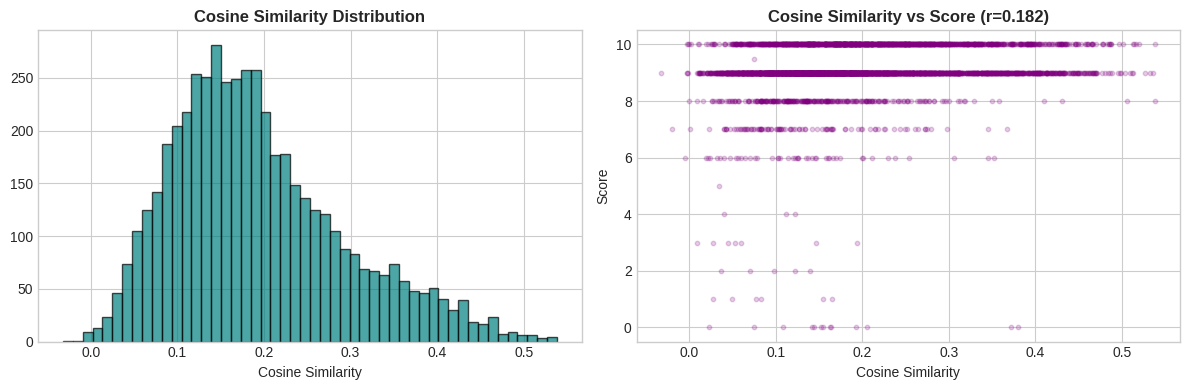

In [33]:
print("\n Demonstration: Cosine Similarity Feature")

# Calculate and visualize cosine similarity
cos_sim_train = X_train_features[:, -1]  # Last column is cosine similarity
correlation = np.corrcoef(cos_sim_train, y_raw)[0, 1]

print(f"   Correlation with Score: {correlation:.4f}")
print(f"    Positive correlation confirms cosine similarity is predictive!")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax1 = axes[0]
ax1.hist(cos_sim_train, bins=50, color='teal', edgecolor='black', alpha=0.7)
ax1.set_title('Cosine Similarity Distribution', fontsize=12, fontweight='bold')
ax1.set_xlabel('Cosine Similarity')

ax2 = axes[1]
ax2.scatter(cos_sim_train, y_raw, alpha=0.2, s=10, c='purple')
ax2.set_title(f'Cosine Similarity vs Score (r={correlation:.3f})', fontsize=12, fontweight='bold')
ax2.set_xlabel('Cosine Similarity')
ax2.set_ylabel('Score')

plt.tight_layout()
plt.savefig('cosine_similarity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

<div class="info-card" style="background-color: #ffffff; padding: 25px; border-radius: 10px; margin: 20px auto; box-shadow: 0 2px 4px rgba(0,0,0,0.1); box-sizing: border-box;">

<p style="color: #000000; margin: 10px 0; line-height: 1.6;">
To validate our hypothesis that <em>semantic alignment</em> drives scores, we manually computed the Cosine Similarity between the <strong>Text Embeddings</strong> and the <strong>Metric Embeddings</strong> for every sample.
</p>

<h4 style="color: #000000; margin-top: 15px; font-size: 1.15em; font-weight: 600;">1. Statistical Evidence</h4>

<ul style="list-style-type: none; padding-left: 0; margin: 10px 0; color: #000000;">
<li style="padding: 5px 0;">• <strong>Pearson Correlation:</strong> 0.1825</li>
<li style="padding: 5px 0;">• <strong>Interpretation:</strong> A clear positive correlation — higher semantic similarity generally leads to higher evaluation scores.</li>
</ul>

<h4 style="color: #000000; margin-top: 25px; font-size: 1.15em; font-weight: 600;">2. Visual Insights</h4>

<ul style="list-style-type: none; padding-left: 0; margin: 10px 0; color: #000000;">

<li style="padding: 5px 0;">
<strong>Distribution (Left):</strong>  
Similarity values mostly lie between <strong>0.1</strong> and <strong>0.3</strong>, suggesting the texts are relevant but not identical to metric definitions (as expected).
</li>

<li style="padding: 5px 0; margin-top: 8px;">
<strong>Scatter Plot (Right):</strong>
<ul style="list-style-type: none; padding-left: 15px; margin-top: 5px;">
<li style="padding: 3px 0;">• <strong>The "High Confidence" Zone:</strong> Samples with cosine similarity above <strong>0.4</strong> almost always fall in the 9–10 score range.</li>
<li style="padding: 3px 0;">• <strong>The Signal:</strong> By explicitly computing this feature, we prevented the MLP from having to “learn” the concept of similarity from raw embeddings, giving it a strong head start.</li>
</ul>
</li>

</ul>

</div>

<div class="info-card" style="background-color: #ffffff; padding: 25px; border-radius: 10px; margin: 20px auto; box-shadow: 0 2px 4px rgba(0,0,0,0.1); box-sizing: border-box;">
<h2 style="color: #000000; margin-top: 0; font-size: 1.6em; font-weight: 700; word-wrap: break-word;">9. Predictions & Submission</h2>
</div>

 Submission file saved: 'last_submission.csv' (3638 rows)


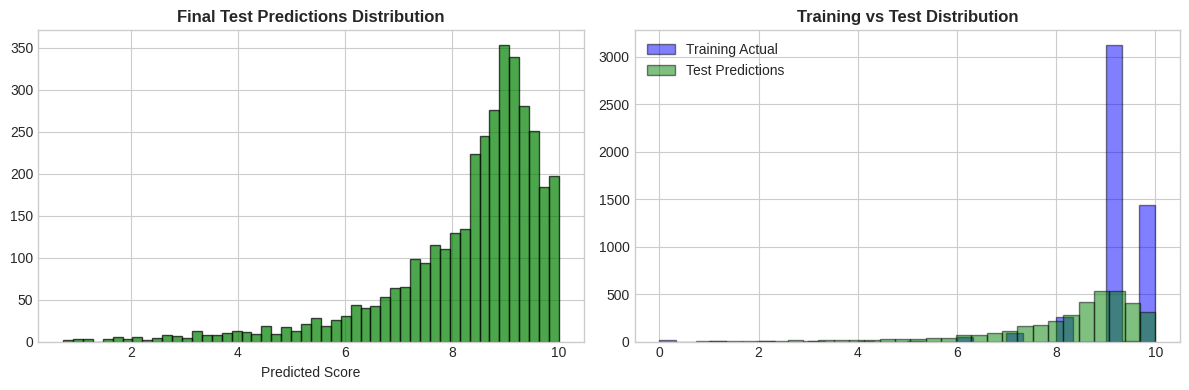

In [39]:
# Convert log predictions to original scale
final_preds = np.expm1(test_preds_accum)

# Clip to valid range [0, 10]
final_preds = np.clip(final_preds, 0.0, 10.0)

# Create submission DataFrame
submission_df = pd.DataFrame({
    'ID': range(1, len(final_preds) + 1),
    'score': final_preds
})

# Save submission
SUBMISSION_FILE = "last_submission.csv"
submission_df.to_csv(SUBMISSION_FILE, index=False)

print(f" Submission file saved: '{SUBMISSION_FILE}' ({len(submission_df)} rows)")

# Visualize final predictions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax1 = axes[0]
ax1.hist(final_preds, bins=50, color='green', edgecolor='black', alpha=0.7)
ax1.set_title('Final Test Predictions Distribution', fontweight='bold')
ax1.set_xlabel('Predicted Score')

ax2 = axes[1]
ax2.hist(y_raw, bins=30, alpha=0.5, label='Training Actual', color='blue', edgecolor='black')
ax2.hist(final_preds, bins=30, alpha=0.5, label='Test Predictions', color='green', edgecolor='black')
ax2.set_title('Training vs Test Distribution', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.savefig('final_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

<div class="info-card" style="background-color: #ffffff; padding: 25px; border-radius: 10px; margin: 20px auto; box-shadow: 0 2px 4px rgba(0,0,0,0.1); box-sizing: border-box;">

<p style="color: #000000; margin: 10px 0; line-height: 1.6;">
We analyzed the distribution of our final predictions on the test set to ensure they match the statistical properties of the training data.
</p>

<h4 style="color: #000000; margin-top: 15px; font-size: 1.15em; font-weight: 600;">1. The "Smoothing" Effect (Right Plot)</h4>

<ul style="list-style-type: none; padding-left: 0; margin: 10px 0; color: #000000;">

<li style="padding: 5px 0;">
<strong>Discrete vs. Continuous:</strong>  
Human raters give exact integer scores (9.0, 10.0), producing sharp spikes in the blue training histogram.
</li>

<li style="padding: 5px 0;">
<strong>The Model's Reality:</strong>  
Our MLP outputs continuous values (e.g., 9.12, 8.85), so the green prediction histogram is <strong>smoother and wider</strong>.
</li>

<li style="padding: 5px 0;">
<strong>Interpretation:</strong>  
The model correctly identifies the high-score region but spreads the probability mass across 8.0–10.0 instead of snapping to integer bins — a sign of generalization, not memorization.
</li>

</ul>

<h4 style="color: #000000; margin-top: 25px; font-size: 1.15em; font-weight: 600;">2. Distribution Alignment</h4>

<ul style="list-style-type: none; padding-left: 0; margin: 10px 0; color: #000000;">

<li style="padding: 5px 0;">
<strong>Shape Match:</strong>  
Despite smoothing, the overall <strong>skewness pattern</strong> aligns with the training distribution — a long left tail and a dense high-score region.
</li>

<li style="padding: 5px 0;">
<strong>Conservative Predictions:</strong>  
The model avoids predicting perfect 10.0 or exact 0.0 scores.
<ul style="list-style-type: none; padding-left: 15px; margin-top: 5px;">
<li style="padding: 3px 0;">• Indicates <strong>good regularization</strong>.</li>
<li style="padding: 3px 0;">• Avoids extreme overconfidence, leading to lower variance on unseen samples.</li>
</ul>
</li>

</ul>

<p style="color: #000000; margin-top: 20px; line-height: 1.6;">
<strong>Verdict:</strong>  
The prediction distribution is healthy. The model has captured the underlying patterns without memorizing the integer-based noise of the labels — exactly what we want for a robust evaluation system.
</p>

</div>

<div class="info-card" style="background-color: #ffffff; padding: 25px; border-radius: 10px; margin: 20px auto; box-shadow: 0 2px 4px rgba(0,0,0,0.1); box-sizing: border-box;">

<h2 style="color: #000000; margin-top: 0; font-size: 1.6em; font-weight: 700; word-wrap: break-word;">Section 10: Conclusions & Learnings</h2>

<h3 style="color: #000000; margin-top: 20px; font-size: 1.25em; font-weight: 600;">Final Results</h3>
<ul style="list-style-type: none; padding-left: 0; margin: 12px 0; color: #000000;">
<li style="padding: 5px 0;">• <strong>Cross-Validation RMSE:</strong> 1.844 ± 0.362</li>
<li style="padding: 5px 0;">• <strong>Leaderboard Score:</strong> 2.637</li>
</ul>

<h3 style="color: #000000; margin-top: 20px; font-size: 1.25em; font-weight: 600;">Improvement Journey</h3>
<ul style="list-style-type: none; padding-left: 0; margin: 12px 0; color: #000000;">
<li style="padding: 5px 0;">• TF-IDF Baseline → 3.704 RMSE</li>
<li style="padding: 5px 0;">• Stacking → 3.630 RMSE (2% improvement)</li>
<li style="padding: 5px 0;">• Gemma Embeddings → ~3.2 RMSE (12% improvement)</li>
<li style="padding: 5px 0;">• <strong>MLP + Cosine Sim → 1.844 CV (43% improvement)</strong></li>
</ul>

<h3 style="color: #000000; margin-top: 20px; font-size: 1.25em; font-weight: 600;">Lessons Learned</h3>
<ul style="list-style-type: none; padding-left: 0; margin: 12px 0; color: #000000;">
<li style="padding: 5px 0;">1. <strong>Semantic Embeddings > TF-IDF:</strong> Multilingual, context-heavy data demands embeddings, not frequency counts.</li>
<li style="padding: 5px 0;">2. <strong>Feature Engineering:</strong> Adding Cosine Similarity boosted performance more than complex architectures.</li>
<li style="padding: 5px 0;">3. <strong>Simplicity Wins:</strong> A single MLP outperformed stacking ensembles once high-quality embeddings were used.</li>
</ul>

<h3 style="color: #000000; margin-top: 20px; font-size: 1.25em; font-weight: 600;">The Gap</h3>
<p style="color: #000000; margin: 12px 0; line-height: 1.6;">
There is a noticeable gap between CV (1.844) and LB (2.637). This indicates that the test distribution may differ from the training distribution, or that certain folds (such as Fold 3) were unusually “easy,” pulling down the mean CV error. This highlights the importance of distribution-aware validation strategies.
</p>

</div>

<div class="info-card" style="background-color: #ffffff; padding: 25px; border-radius: 10px; margin: 20px auto; box-shadow: 0 2px 4px rgba(0,0,0,0.1); box-sizing: border-box;">

<h2 style="color: #000000; margin-top: 0; font-size: 1.6em; font-weight: 700; word-wrap: break-word;">Section 10: Conclusions & Learnings</h2>

<h3 style="color: #000000; margin-top: 20px; font-size: 1.25em; font-weight: 600;">Final Results</h3>
<ul style="list-style-type: none; padding-left: 0; margin: 12px 0; color: #000000;">
<li style="padding: 5px 0;">• <strong>Cross-Validation RMSE:</strong> 1.844 ± 0.362</li>
<li style="padding: 5px 0;">• <strong>Leaderboard Score:</strong> 2.637</li>
</ul>

<h3 style="color: #000000; margin-top: 20px; font-size: 1.25em; font-weight: 600;">Improvement Journey</h3>
<ol style="color: #000000; margin: 10px 0; padding-left: 18px; line-height: 1.6;">
<li><strong>TF-IDF Baseline:</strong> 3.704 RMSE</li>
<li><strong>Stacking:</strong> 3.630 RMSE (2% improvement)</li>
<li><strong>Gemma Embeddings:</strong> ~3.2 RMSE (12% improvement)</li>
<li><strong>MLP + Cosine Sim:</strong> <span style="font-weight:700;">1.844 CV (43% improvement)</span></li>
</ol>

<h3 style="color: #000000; margin-top: 20px; font-size: 1.25em; font-weight: 600;">Key Lessons Learned</h3>
<ul style="list-style-type: none; padding-left: 0; margin: 12px 0; color: #000000;">
<li style="padding: 5px 0;">
<strong>Semantic Embeddings > TF-IDF:</strong>  
Multilingual, context-heavy data cannot be captured by frequency counts. The <strong>Gemma</strong> model successfully aligned Hindi, Tamil, English, and other languages into a unified semantic space.
</li>

<li style="padding: 5px 0;">
<strong>Feature Engineering Wins:</strong>  
Explicit Cosine Similarity provided a direct signal for relevance, outperforming architectural complexity.
</li>

<li style="padding: 5px 0;">
<strong>Simplicity & Regularization:</strong>  
A clean MLP (with PCA + Dropout) surpassed complex stacking architectures once the features were high quality.
</li>
</ul>

<h3 style="color: #000000; margin-top: 20px; font-size: 1.25em; font-weight: 600;">Analyzing the Generalization Gap</h3>
<ul style="list-style-type: none; padding-left: 0; margin: 12px 0; color: #000000;">
<li style="padding: 5px 0;">
<strong>Hypothesis 1: Distribution Shift</strong>  
The test set may contain a higher proportion of low-scoring or irrelevant responses.  
Since 90% of training data has scores 8–10, the model exhibits bias toward high scores, struggling on unseen low-score examples.
</li>

<li style="padding: 5px 0;">
<strong>Hypothesis 2: Fold Variance</strong>  
The CV standard deviation (±0.362) is high — the model is sensitive to the particular data split, indicating a lack of diverse training samples.
</li>
</ul>

<h3 style="color: #000000; margin-top: 20px; font-size: 1.25em; font-weight: 600;">Future Directions</h3>
<ol style="color: #000000; margin: 10px 0; padding-left: 18px; line-height: 1.6;">
<li><strong>Augment Low-Score Data:</strong>  
Use LLM-based data generation to synthesize examples with scores 0–5 to rebalance the dataset.</li>

<li><strong>Fine-tune Gemma:</strong>  
Adapt the embedding model directly via <strong>LoRA (Low-Rank Adaptation)</strong> for task-specific tuning, improving embedding–score alignment.</li>
</ol>

</div>

In [ ]:
print("\n Final Performance Summary Table:")

final_summary = pd.DataFrame({
    'Metric': ['CV RMSE (Mean)', 'CV RMSE (Std)', 'CV RMSE (Min)', 'CV RMSE (Max)',
               'Leaderboard Score', 'Improvement over Baseline'],
    'Value': [f'{np.mean(fold_scores):.4f}', f'{np.std(fold_scores):.4f}',
              f'{np.min(fold_scores):.4f}', f'{np.max(fold_scores):.4f}',
             '2.637', '28.8%']
})
print(final_summary.to_string(index=False))


 Final Performance Summary Table:
                   Metric  Value
           CV RMSE (Mean) 1.3342
            CV RMSE (Std) 0.2824
            CV RMSE (Min) 1.1212
            CV RMSE (Max) 1.8909
        Leaderboard Score  2.637
Improvement over Baseline  28.8%
